In [2]:
!pip install fastapi uvicorn pydantic nest-asyncio pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.3 MB/s eta 0:00:00


<ipython-input-3-f250ee5bdd5e>:40: DeprecationWarning: `example` has been deprecated, please use `examples` instead
  def view_patient(patient_id:str=Path(...,description="ID of the patients in the Database",example="P001,P002,,,,,")):


Public URL: NgrokTunnel: "https://4f60-104-196-11-246.ngrok-free.app" -> "http://localhost:8000"


INFO:     Started server process [762]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2402:a00:405:ddd0:eda1:6a2e:56fc:f694:0 - "GET / HTTP/1.1" 200 OK
INFO:     2402:a00:405:ddd0:eda1:6a2e:56fc:f694:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     2402:a00:405:ddd0:eda1:6a2e:56fc:f694:0 - "GET /about HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [762]


# Recap what we have till now

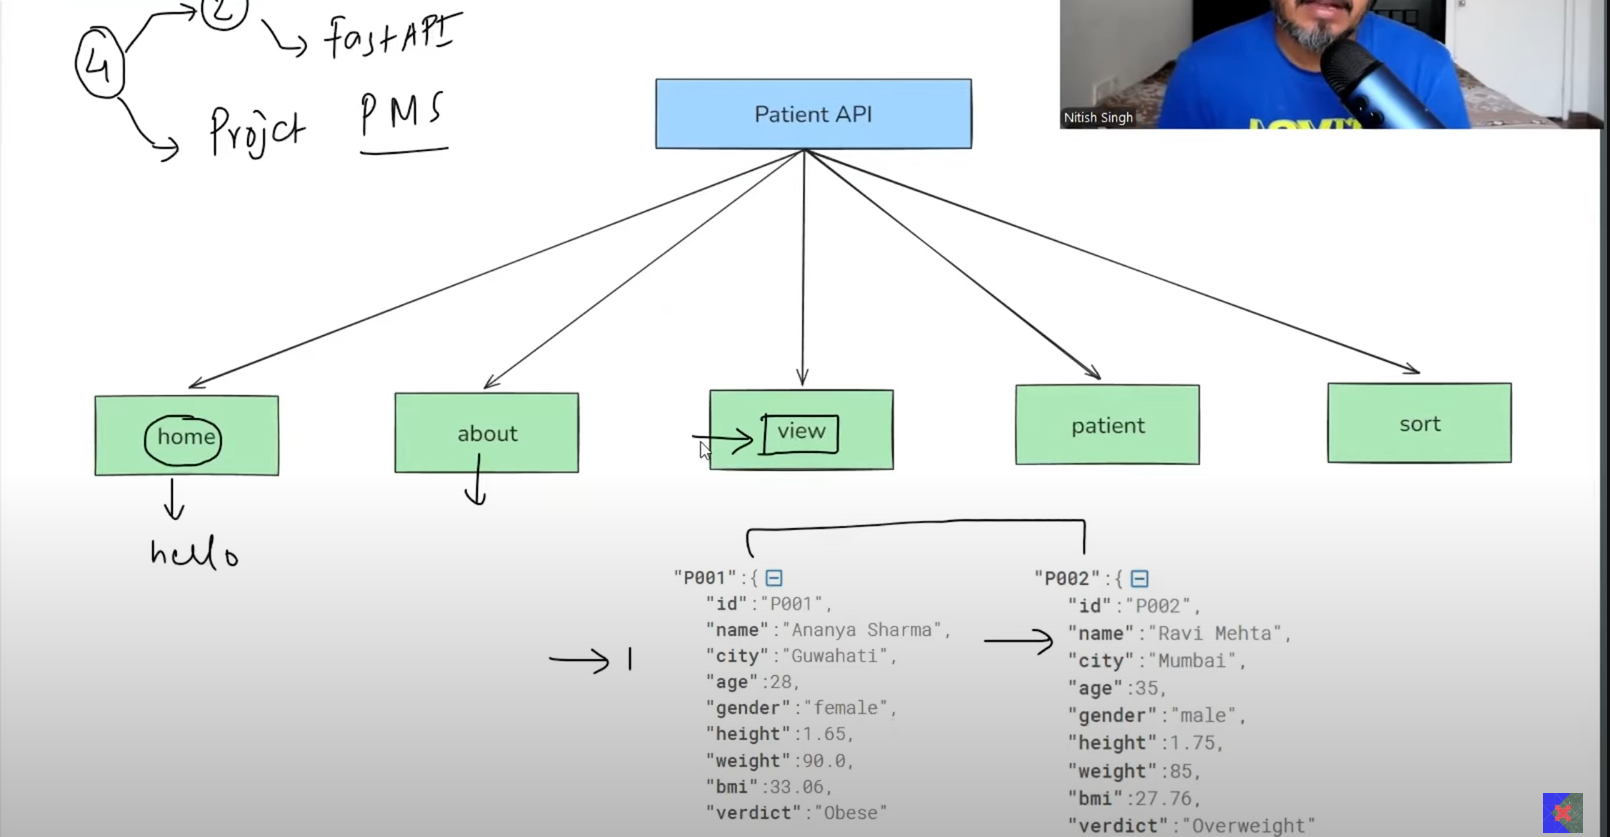

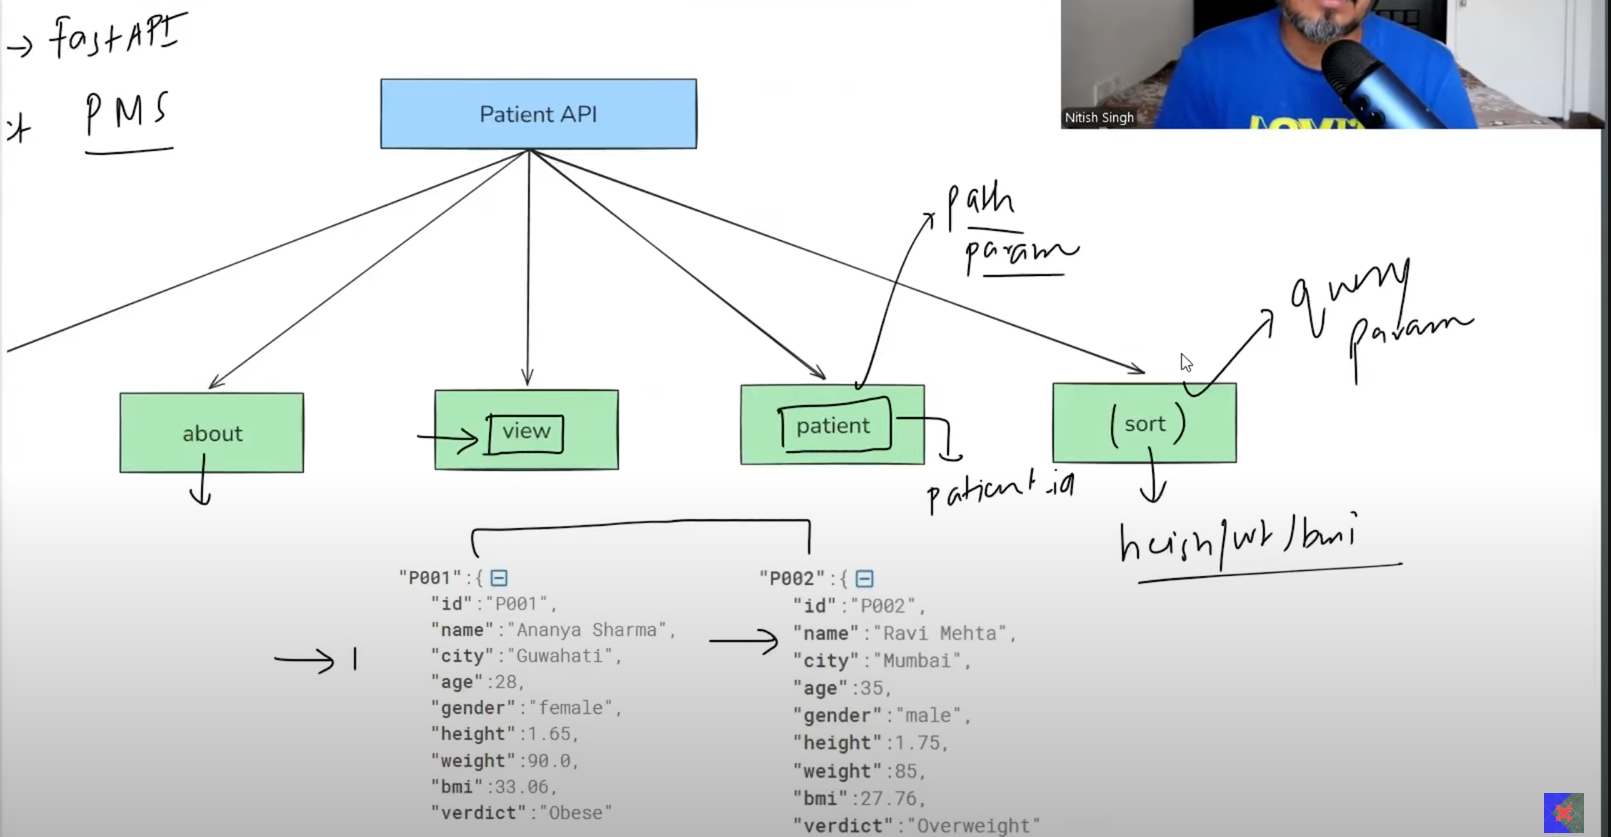

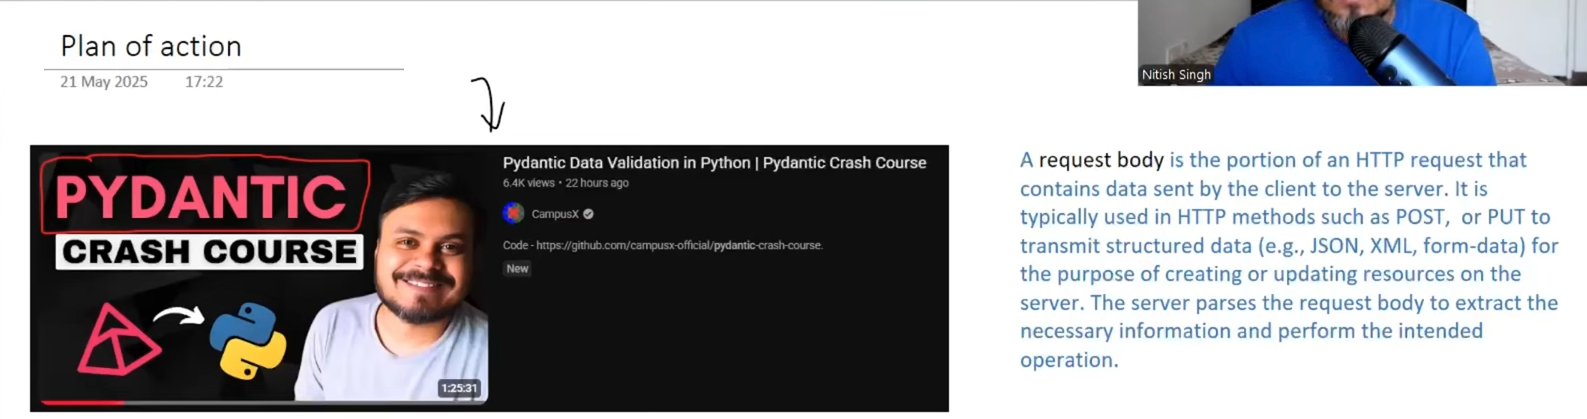

step1:- first we will send the data
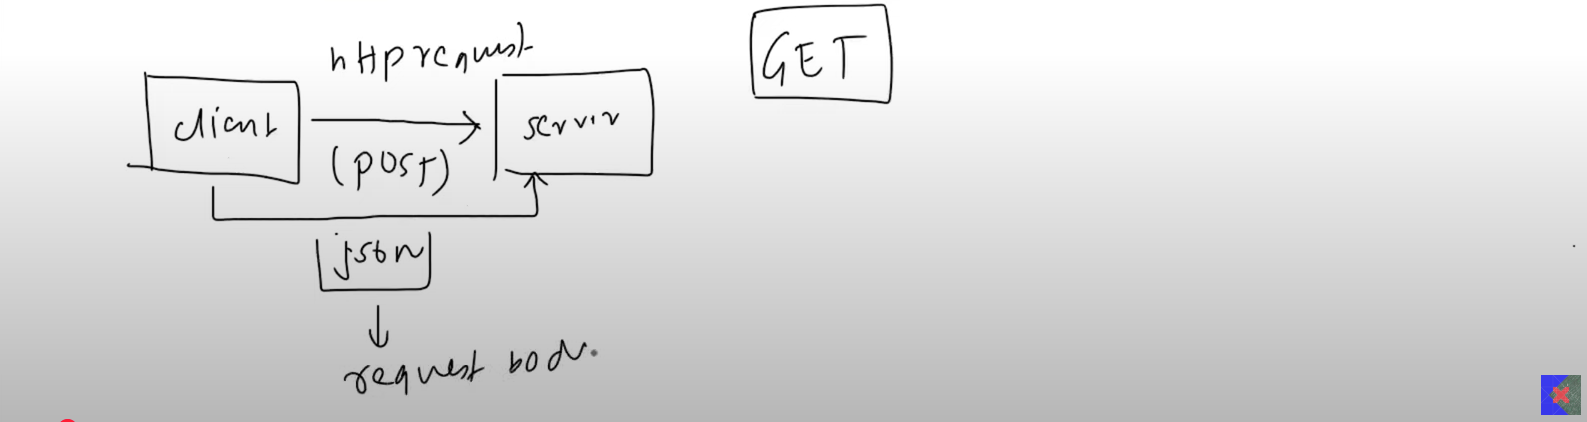

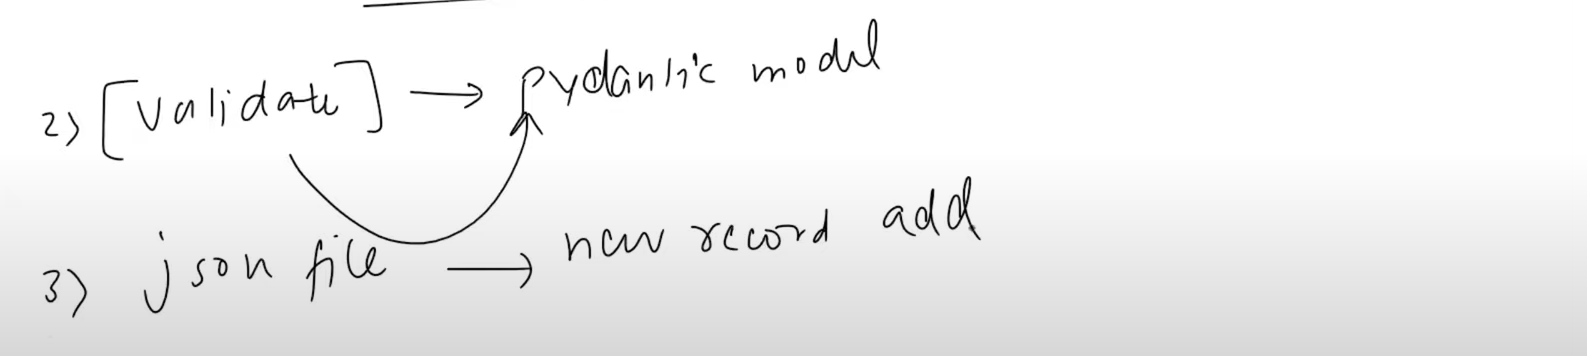

In [9]:
from time import daylight
from fastapi import FastAPI,Path,HTTPException,Query
from fastapi.responses import JSONResponse

import nest_asyncio
from pyngrok import ngrok
import uvicorn
import json
from google.colab import userdata

from pydantic import BaseModel,Field,computed_field
from typing import Annotated,Literal



# setting ngrok
ngrok_auth_token = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(ngrok_auth_token)


# running instance of the fast api
app = FastAPI()


# creating pydantic object
class Patient(BaseModel):
  id:Annotated[str,Field(...,description='ID of the patient',example='P001')]
  name:Annotated[str,Field(... , description="Name of the patient")]
  age:Annotated[int,Field(... , gt=0,lt=120,description="Age of the patient")]
  city:Annotated[str,Field(... , description="City where the patient is living")]
  gender:Annotated[Literal['male','female','other'],Field(description="gender of the Patient")]
  height:Annotated[float,Field(... , gt=0,description="Height of the patient in meter")]
  weight:Annotated[float,Field(... , gt=0,description="Weight of the patient in kg")]


  @computed_field
  @property
  def bmi(self)->float:
    bmi=round(self.weight/(self.height**2))
    return bmi

  @computed_field
  @property
  def verdict(self)->str:
    if self.bmi <18.5:
      return "Underweight"
    elif 18.5<=self.bmi<25:
      return "Normal"
    elif 25<=self.bmi<30:
      return "Overweight"


# function to load the datta from patients.json
def load_data():
  with open('/content/patients.json') as f:
    data = json.load(f)
  return data

# function to save data
def save_data(data):
  with open('/content/patients.json','w') as f:
    json.dump(data,f)



# first router for first endpoint
@app.get("/")
def Hello():
  return {"Message":"Patient Management System Api"}

@app.get('/about')
def about():
  return {"message":"A fully functional API tomanage your patients records"}

@app.get('/view') # this will display all the details of the patients
def view():
  data=load_data()
  return data

@app.get('/patient/{patient_id}')
def view_patient(patient_id:str=Path(...,description="ID of the patients in the Database",example="P001,P002,,,,,")):
  #loading all the patiennts
  data=load_data()

  if patient_id in data:
    return data[patient_id]
  raise HTTPException(status_code=404,detail="patient not found")

@app.get('/sor')
def sort_pateints(sort_by:str =Query(...,description="sort on the basis of height ,weights or bmi"),order:str=Query('asc',description="sort in asc or desc order")):
  valid_filed=["height","weight","bmi"]

  if sort_by not in valid_filed:
    raise HTTPException(status_code=400,detail="Invalid field select from height,weight,bmi")

  if order not in ['asc','desc']:
    raise HTTPException(status_code=400,detail="invalid order select between asc and desc")

  data=load_data()

  sort_order=True if order=="desc" else False

  sorted_data=sorted(data.values(),key=lambda x:x.get(sort_by,0),reverse=sort_order)

  return sorted_data



@app.post('/create')
def create_patient(patient:Patient):

  #step1:-loading existing data
  data=load_data()


  #step2:-checkif the patient already exist
  if patient.id in data:
    raise HTTPException(status_code=400,detail="patient already exist")

  #step3:-new patient add to the database
  """NOTE: patient is Pydantic Object where as data is a dictionary both are not same datatype
            therefore we need conversion of Pydantic object to dictionary and viceversa"""
  data[patient.id]=patient.model_dump(exclude='id')

  #step4:-saving info into json file
  save_data(data)

  #step5:-tell the clien that everthing is successful by returing the response
  return JSONResponse(status_code=200,content={'message':'patient created successfully'})






# Apply nest_asyncio to allow running uvicorn inside notebook
nest_asyncio.apply()

# Open an ngrok tunnel to the default uvicorn port 8000
public_url = ngrok.connect(8000)
print(f"Public URL: {public_url}")

# Run the FastAPI app
uvicorn.run(app, host="0.0.0.0", port=8000)

<ipython-input-9-a77b060c5a7a>:81: DeprecationWarning: `example` has been deprecated, please use `examples` instead
  def view_patient(patient_id:str=Path(...,description="ID of the patients in the Database",example="P001,P002,,,,,")):


Public URL: NgrokTunnel: "https://77e4-104-196-11-246.ngrok-free.app" -> "http://localhost:8000"


INFO:     Started server process [762]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2402:a00:405:ddd0:eda1:6a2e:56fc:f694:0 - "GET / HTTP/1.1" 200 OK
INFO:     2402:a00:405:ddd0:eda1:6a2e:56fc:f694:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     2402:a00:405:ddd0:eda1:6a2e:56fc:f694:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     2402:a00:405:ddd0:eda1:6a2e:56fc:f694:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     2402:a00:405:ddd0:eda1:6a2e:56fc:f694:0 - "POST /create HTTP/1.1" 400 Bad Request
INFO:     2402:a00:405:ddd0:eda1:6a2e:56fc:f694:0 - "POST /create HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [762]
